In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')

# Drop unnecessary columns
df.drop(columns=['Unnamed: 0'], inplace=True)

# Convert 'month' to datetime
df['month'] = pd.to_datetime(df['month'])

# Check for and handle missing values here if necessary
# For example, you might decide to fill missing values or drop rows/columns with missing data

# Encode categorical variables
le_practice = LabelEncoder()
le_company = LabelEncoder()
le_supersector = LabelEncoder()

df['practice_encoded'] = le_practice.fit_transform(df['practice'])
df['company_encoded'] = le_company.fit_transform(df['Company Name Full'])
df['supersector_encoded'] = le_supersector.fit_transform(df['Supersector'])


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/1051472472.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Example: Creating a lag feature for the 'score' column
df.sort_values(by=['Company Name Full', 'month'], inplace=True)
df['score_lag1'] = df.groupby('Company Name Full')['score'].shift(1)


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Select features and target
X = df[['practice_encoded', 'company_encoded', 'supersector_encoded', 'score_lag1']]  # Add more features as needed
y = df['score']

# Handle NaN values in features, for example by filling with 0
X.fillna(0, inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/3679014502.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(0, inplace=True)


In [4]:
# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the testing set
predictions = model.predict(X_test)


In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# 1. Datenvorbereitung
def adjust_scores_to_never_decrease(df, group_columns, score_column):
    df = df.sort_values(by=group_columns + ['month'], ascending=True)
    def adjust_group_scores(group):
        group[score_column] = group[score_column].cummax()
        return group
    return df.groupby(group_columns, as_index=False).apply(adjust_group_scores).reset_index(drop=True)

# Laden Sie Ihre Daten
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')
df['month'] = pd.to_datetime(df['month'])  # Stellen Sie sicher, dass 'month' als Datumsfeld vorliegt

# Anpassen der Scores, damit diese nicht abnehmen
adjusted_df = adjust_scores_to_never_decrease(df, ['Company Name Full', 'practice'], 'score')

# 2. Vorverarbeitung
# Kodieren kategorialer Variablen
label_encoders = {}
for column in ['practice', 'Company Name Full', 'Supersector']:
    le = LabelEncoder()
    adjusted_df[column + '_encoded'] = le.fit_transform(adjusted_df[column])
    label_encoders[column] = le

# Features und Target definieren
features = ['practice_encoded', 'Company Name Full_encoded', 'Supersector_encoded']
X = adjusted_df[features]
y = adjusted_df['score']

# 3. Trainings- und Testdaten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Modelltraining
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Optional: Modellbewertung durchführen, z.B. mit X_test und y_test


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/3789765264.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_columns, as_index=False).apply(adjust_group_scores).reset_index(drop=True)


RandomForestRegressor(random_state=42)

In [35]:
# Machen Sie Vorhersagen auf dem Testdatensatz
y_pred = model.predict(X_test)


In [37]:
# Konvertierung des 'month' in datetime
filtered_df['month'] = pd.to_datetime(filtered_df['month'])

# Anwendung der LabelEncoder, die beim Training verwendet wurden
filtered_df['practice_encoded'] = label_encoders['practice'].transform(filtered_df['practice'])
filtered_df['company_encoded'] = label_encoders['Company Name Full'].transform(filtered_df['Company Name Full'])
filtered_df['supersector_encoded'] = label_encoders['Supersector'].transform(filtered_df['Supersector'])


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/807860291.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['month'] = pd.to_datetime(filtered_df['month'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/807860291.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['practice_encoded'] = label_encoders['practice'].transform(filtered_df['practice'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/807860291.py:6: SettingWithCopyWarnin

In [40]:
from datetime import datetime
from dateutil.relativedelta import relativedelta


# Letztes Datum im Datensatz finden
last_date = filtered_df['month'].max()

# Zukünftige Datenpunkte für die nächsten 12 Monate erzeugen
future_months = [last_date + relativedelta(months=i) for i in range(1, 13)]
future_df = pd.DataFrame(future_months, columns=['month'])

# Kreuzprodukt der einzigartigen Kombinationen von Unternehmen und Praxis mit den zukünftigen Monaten
companies_practices = filtered_df[['company_encoded', 'practice_encoded']].drop_duplicates()
future_df = future_df.assign(key=1)  # Hilfsspalte für das Kreuzprodukt
companies_practices = companies_practices.assign(key=1)  # Hilfsspalte
future_df = pd.merge(future_df, companies_practices, on='key').drop('key', axis=1)

# Fügen Sie nötige Features hinzu und setzen Sie diese auf Durchschnittswerte oder Nullen
# Beispiel: future_df['ein_feature'] = 0  # Anpassen basierend auf Ihren Modellfeatures


In [42]:
import pandas as pd
from dateutil.relativedelta import relativedelta

# Annahme: 'filtered_df' ist Ihr vorbereiteter DataFrame und 'model' ist Ihr trainiertes Modell

# Konvertieren des 'month' in datetime (falls noch nicht geschehen)
filtered_df['month'] = pd.to_datetime(filtered_df['month'])

# Berechnen der encoded Spalten für practice und company (falls noch nicht geschehen)
filtered_df['practice_encoded'] = label_encoders['practice'].transform(filtered_df['practice'])
filtered_df['company_encoded'] = label_encoders['Company Name Full'].transform(filtered_df['Company Name Full'])

# Letztes Datum im Datensatz finden
last_date = filtered_df['month'].max()

# Zukünftige Datenpunkte für die nächsten 12 Monate erzeugen
future_months = [last_date + relativedelta(months=i) for i in range(1, 13)]
future_df = pd.DataFrame(future_months, columns=['month'])

# Berechnen der zukünftigen company_encoded und practice_encoded Werte basierend auf vorhandenen Kombinationen
# Hinweis: Da 'supersector_encoded' nicht direkt verfügbar ist, lassen wir es aus den Vorhersagen heraus, 
# falls es nicht kritisch ist oder wir setzen es auf einen Standardwert (z.B. 0 oder den Modus)
companies_practices = filtered_df[['company_encoded', 'practice_encoded']].drop_duplicates()
future_df['key'] = 1  # Hilfsspalte für das Kreuzprodukt
companies_practices['key'] = 1
future_df = pd.merge(future_df, companies_practices, on='key').drop(columns='key')

# Hier fügen wir eine Annahme für 'supersector_encoded' hinzu, falls benötigt
# future_df['supersector_encoded'] = 0  # Oder einen anderen repräsentativen Wert

# Stellen Sie sicher, dass die Spalten, die Ihr Modell erwartet, vorhanden sind:
# X_future = future_df[['practice_encoded', 'company_encoded', ...]]  # Ergänzen Sie entsprechend

# Vorhersagen machen
# Achten Sie darauf, die tatsächlichen Feature-Namen anzupassen
X_future = future_df[['practice_encoded', 'company_encoded']]  # Beispiel
future_df['predicted_score'] = model.predict(X_future)

# Ergebnisse anzeigen oder speichern
print(future_df)
# Optional: Speichern der Ergebnisse
# future_df.to_csv('/pfad/zur/speicherung/zukuenftige_vorhersagen.csv', index=False)


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/2779043498.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['month'] = pd.to_datetime(filtered_df['month'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/2779043498.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['practice_encoded'] = label_encoders['practice'].transform(filtered_df['practice'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/2779043498.py:11: SettingWithCopyW

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- company_encoded
Feature names seen at fit time, yet now missing:
- Company Name Full_encoded
- Supersector_encoded


In [41]:
# Sicherstellen, dass future_df die richtigen Spalten für Ihr Modell enthält
X_future = future_df[['practice_encoded', 'company_encoded', 'supersector_encoded']]  # Anpassen an Ihre Features

# Vorhersagen machen
future_df['predicted_score'] = model.predict(X_future)


KeyError: "['supersector_encoded'] not in index"

In [36]:
print(y_pred)

[5.21449756 2.76145975 8.57886084 ... 0.         3.94661142 3.52336504]


In [26]:
import pandas as pd

# Load the new CSV file
new_df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/merged.csv')

# Filter the dataframe
filtered_df = new_df[(new_df['practice'] == 'BMI-CCF-Core Development') & (new_df['Company Name Full'] == 'VESTAS WIND SYSTEMS')]

filtered_df.head()

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
37962,37962,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2021-01,Oil & Gas,CCF,BMI,24.925944,0.0,0.0,2.535435,7.052156,10.950612,24.925944,37.614442,54.965384,156.235794,421.122024,5
37963,37963,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2021-02,Oil & Gas,CCF,BMI,47.751421,0.0,0.0,4.818074,19.570925,115.165702,293.897564,307.536522,352.957316,576.711289,1432.499266,4
37964,37964,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2021-03,Oil & Gas,CCF,BMI,11.109735,0.0,0.0,0.000000,0.000000,9.584068,14.968492,51.979978,262.775695,609.874969,1994.713533,5
37965,37965,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2021-04,Oil & Gas,CCF,BMI,122.186333,0.0,0.0,0.000000,18.861110,78.575313,122.186333,215.399998,285.568146,414.925114,1732.235863,5
37966,37966,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2021-05,Oil & Gas,CCF,BMI,235.712138,0.0,0.0,0.000000,0.000000,30.341712,199.412400,239.748834,286.477561,326.981907,960.252603,6


In [27]:
# Assuming 'new_df' is your new data
filtered_df['month'] = pd.to_datetime(filtered_df['month'])  # Ensure month is datetime
filtered_df['practice_encoded'] = le_practice.transform(filtered_df['practice'])
filtered_df['company_encoded'] = le_company.transform(filtered_df['Company Name Full'])
filtered_df['supersector_encoded'] = le_supersector.transform(filtered_df['Supersector'])

# Calculate any derived features as per your model's training (e.g., lagged scores)
filtered_df.sort_values(by=['Company Name Full', 'month'], inplace=True)
filtered_df['score_lag1'] = filtered_df.groupby('Company Name Full')['score'].shift(1)

# Prepare the feature set for prediction
new_X = filtered_df[['practice_encoded', 'company_encoded', 'supersector_encoded', 'score_lag1']]  # Include other features if used

# Handle missing values in the features if necessary
new_X.fillna(0, inplace=True)

# Make predictions
predictions = model.predict(new_X)


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/537365764.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['month'] = pd.to_datetime(filtered_df['month'])  # Ensure month is datetime
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/537365764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['practice_encoded'] = le_practice.transform(filtered_df['practice'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/537365764.py:4: SettingW

In [22]:
print(predictions)

[1.0025986  1.0025986  1.91601002 1.0025986  1.91601002 1.0025986
 1.0025986  1.0025986  1.0025986  1.91601002 1.0025986  1.0025986
 1.0025986  1.0025986  3.29496609 1.0025986  3.29496609 1.0025986
 1.0025986  1.0025986  1.91601002 1.0025986  1.0025986  1.0025986
 1.91601002 1.0025986  5.09769048 1.0025986  1.91601002 1.91601002
 1.0025986  1.0025986  1.91601002 1.0025986  1.0025986  1.0025986
 1.0025986 ]


In [30]:
filtered_df.tail()

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,...,p70,p80,p90,p100,score,practice_encoded,company_encoded,supersector_encoded,score_lag1,adjusted_predicted_score
37994,37994,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2023-09-01,Oil & Gas,CCF,BMI,37.509555,0.0,0.0,...,34.942044,47.652597,128.792564,243.909348,7,1,496,11,7.0,6.079996
37995,37995,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2023-10-01,Oil & Gas,CCF,BMI,25.828892,0.0,0.0,...,99.066104,218.599206,312.763621,332.484885,5,1,496,11,7.0,6.079996
37996,37996,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2023-11-01,Oil & Gas,CCF,BMI,13.441312,0.0,0.0,...,108.412069,306.326151,367.324733,868.715956,6,1,496,11,5.0,6.079996
37997,37997,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2023-12-01,Oil & Gas,CCF,BMI,405.847671,0.0,0.0,...,23.682994,32.690457,108.294218,405.847671,9,1,496,11,6.0,6.079996
37998,37998,BMI-CCF-Core Development,VESTAS WIND SYSTEMS,2024-01-01,Oil & Gas,CCF,BMI,11.168264,0.0,0.0,...,63.985395,115.236489,134.914631,177.017940,5,1,496,11,9.0,6.079996


In [28]:
def enforce_non_decreasing(predictions):
    """
    Adjusts predictions to ensure each value is at least as large as the previous one.

    :param predictions: List or array of predicted scores.
    :return: Adjusted predictions.
    """
    adjusted_predictions = predictions.copy()
    for i in range(1, len(adjusted_predictions)):
        adjusted_predictions[i] = max(adjusted_predictions[i], adjusted_predictions[i-1])
    return adjusted_predictions

# Assuming 'predictions' is your array of model predictions
adjusted_predictions = enforce_non_decreasing(predictions)

# Add the adjusted predictions back to your DataFrame
filtered_df['adjusted_predicted_score'] = adjusted_predictions


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/1471522353.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['adjusted_predicted_score'] = adjusted_predictions


In [29]:
print(adjusted_predictions)

[3.99445009 3.99445009 3.99445009 3.99445009 3.99445009 3.99445009
 3.99445009 3.99445009 3.99445009 3.99445009 3.99445009 3.99445009
 3.99445009 3.99445009 6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554]


In [31]:
def adjust_predictions_to_non_decreasing_with_initial_constraint(predictions, last_known_score):
    """
    Adjusts the predictions to ensure that they are non-decreasing and that the
    first prediction is at least as high as the last known score.

    :param predictions: List or array of predicted scores.
    :param last_known_score: The last known score from the new data.
    :return: Adjusted predictions.
    """
    adjusted_predictions = predictions.copy()
    
    # Ensure the first prediction is at least as high as the last known score
    adjusted_predictions[0] = max(adjusted_predictions[0], last_known_score)
    
    # Ensure all subsequent predictions are non-decreasing
    for i in range(1, len(adjusted_predictions)):
        adjusted_predictions[i] = max(adjusted_predictions[i], adjusted_predictions[i-1])
    
    return adjusted_predictions

# Beispielverwendung:
# Nehmen wir an, 'predictions' sind Ihre Modellvorhersagen und 'last_known_score' ist der letzte bekannte Score.
last_known_score = filtered_df['score'].iloc[-1]  # Der letzte bekannte Score aus Ihren neuen Daten
adjusted_predictions = adjust_predictions_to_non_decreasing_with_initial_constraint(predictions, last_known_score)

# Fügen Sie die angepassten Vorhersagen Ihrem DataFrame hinzu
filtered_df['adjusted_predicted_score'] = adjusted_predictions


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_92369/3304842440.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['adjusted_predicted_score'] = adjusted_predictions


In [32]:
print(adjusted_predictions)

[5.         5.         5.         5.         5.         5.
 5.         5.         5.         5.         5.         5.
 5.         5.         6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554 6.07999554
 6.07999554]


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Laden Sie den Datensatz
df = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv')

# 'month' in datetime umwandeln
df['month'] = pd.to_datetime(df['month'])

# Sicherstellen, dass die Scores innerhalb jeder Gruppe von 'Company Name Full' und 'practice' nicht abnehmen
df.sort_values(['Company Name Full', 'practice', 'month'], inplace=True)
df['score'] = df.groupby(['Company Name Full', 'practice'])['score'].cummax()

# Berechnung der Differenz in Monaten zwischen dem aktuellen Monat und dem ersten Monat
df['time_since_start'] = ((df['month'] - df['month'].min()).dt.days / 30.44).astype(int)

# Lag-Features hinzufügen
df['score_lag1'] = df.groupby(['Company Name Full', 'practice'])['score'].shift(1)
df['score_lag1'].fillna(0, inplace=True)  # Füllen Sie fehlende Werte für das erste Lag

# Trainings- und Testdaten aufteilen: Training bis Juni 2023, Testdaten danach
train_df = df[df['month'] <= '2023-06']
test_df = df[df['month'] > '2023-06']

# Kategorische Variablen kodieren
le_practice = LabelEncoder()
le_supersector = LabelEncoder()
train_df['practice_encoded'] = le_practice.fit_transform(train_df['practice'])
train_df['supersector_encoded'] = le_supersector.fit_transform(train_df['Supersector'])

# Gleiche Transformation auf Testdaten anwenden
test_df['practice_encoded'] = le_practice.transform(test_df['practice'])
test_df['supersector_encoded'] = le_supersector.transform(test_df['Supersector'])

# Features für das Training und Testen definieren, inklusive der linearen Zeitkomponente
features = ['practice_encoded', 'supersector_encoded', 'score_lag1', 'time_since_start']

# Modell initialisieren und trainieren
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_df[features], train_df['score'])

# Vorhersagen auf dem Testdatensatz machen
y_pred = model.predict(test_df[features])

# Bewertungsmetriken berechnen
mae = mean_absolute_error(test_df['score'], y_pred)
mse = mean_squared_error(test_df['score'], y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/3865550590.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['score_lag1'].fillna(0, inplace=True)  # Füllen Sie fehlende Werte für das erste Lag
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/3865550590.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

MAE: 0.08139839006400149, MSE: 0.2857527872037083, RMSE: 0.5345584974572084


In [21]:
# Extrahieren Sie die Testdaten ab Juli 2023
test_df = df[df['month'] > '2023-06']

# Berechnen der Differenz in Monaten zwischen dem aktuellen Monat und dem ersten Monat für den Testdatensatz
test_df['time_since_start'] = ((test_df['month'] - df['month'].min()).dt.days / 30.44).astype(int)

# Berechnen der Lag-Features für den Testdatensatz
test_df['score_lag1'] = test_df.groupby(['Company Name Full', 'practice'])['score'].shift(1)
test_df['score_lag1'].fillna(0, inplace=True)  # Füllen Sie fehlende Werte

# Kodieren Sie kategoriale Variablen mit denselben Encodern, die für das Training verwendet wurden
test_df['practice_encoded'] = le_practice.transform(test_df['practice'])
test_df['supersector_encoded'] = le_supersector.transform(test_df['Supersector'])

# Bereiten Sie die Feature-Matrix für den Testdatensatz vor, inklusive der Lag-Features und der linearen Zeitkomponente
X_test = test_df[['practice_encoded', 'supersector_encoded', 'score_lag1', 'time_since_start']]

# Machen Sie Vorhersagen mit dem trainierten Modell
y_pred = model.predict(X_test)

# Berechnen Sie die tatsächlichen Werte aus dem Testdatensatz für die Validierung
y_true = test_df['score']

# Berechnen Sie Bewertungsmetriken, um die Modellleistung zu beurteilen
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"Validation MAE: {mae}")
print(f"Validation MSE: {mse}")
print(f"Validation RMSE: {rmse}")

# Fügen Sie die Vorhersagen als neue Spalte zum test_df hinzu
test_df['predicted_score'] = y_pred

# Optional: Erstellen Sie einen DataFrame, der nur die relevanten Spalten enthält
results_df = test_df[['month', 'Company Name Full', 'practice', 'Supersector', 'score', 'predicted_score']]

# Anzeigen der ersten Zeilen des results_df DataFrame zur Überprüfung
print(results_df.head())


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/1051192970.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['time_since_start'] = ((test_df['month'] - df['month'].min()).dt.days / 30.44).astype(int)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/1051192970.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['score_lag1'] = test_df.groupby(['Company Name Full', 'practice'])['score'].shift(1)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242

Validation MAE: 0.755241764001635
Validation MSE: 5.896534201201814
Validation RMSE: 2.4282780321046054
        month Company Name Full                  practice         Supersector  \
30 2023-07-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
31 2023-08-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
32 2023-09-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
33 2023-10-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
34 2023-11-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   

    score  predicted_score  
30      0              0.0  
31      0              0.0  
32      0              0.0  
33      0              0.0  
34      0              0.0  


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/1051192970.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_score'] = y_pred


In [22]:
results_df.tail(1000)

,month,Company Name Full,practice,Supersector,score,predicted_score
470634,2023-08-01,samhallsbyggnadsbolaget,CE-CNA-Market Adaption,Real Estate,0,0.00000
470635,2023-09-01,samhallsbyggnadsbolaget,CE-CNA-Market Adaption,Real Estate,0,0.00000
470636,2023-10-01,samhallsbyggnadsbolaget,CE-CNA-Market Adaption,Real Estate,0,0.00000
470637,2023-11-01,samhallsbyggnadsbolaget,CE-CNA-Market Adaption,Real Estate,0,0.00000
470638,2023-12-01,samhallsbyggnadsbolaget,CE-CNA-Market Adaption,Real Estate,0,0.00000
...,...,...,...,...,...,...
3255255,2023-09-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.00125
3255256,2023-10-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.00125
3255257,2023-11-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.00125
3255258,2023-12-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.00125


In [24]:
# Extrahieren Sie die Testdaten ab Juli 2023
test_df = df[df['month'] > '2023-06']

# Berechnen der Differenz in Monaten zwischen dem aktuellen Monat und dem ersten Monat für den Testdatensatz
test_df['time_since_start'] = ((test_df['month'] - df['month'].min()).dt.days / 30.44).astype(int)

# Berechnen der Lag-Features für den Testdatensatz
test_df['score_lag1'] = test_df.groupby(['Company Name Full', 'practice'])['score'].shift(1)
test_df['score_lag1'].fillna(0, inplace=True)  # Füllen Sie fehlende Werte für das erste Lag

# Kodieren Sie kategoriale Variablen mit denselben Encodern, die für das Training verwendet wurden
test_df['practice_encoded'] = le_practice.transform(test_df['practice'])
test_df['supersector_encoded'] = le_supersector.transform(test_df['Supersector'])

# Bereiten Sie die Feature-Matrix für den Testdatensatz vor, inklusive der Lag-Features und der linearen Zeitkomponente
X_test = test_df[['practice_encoded', 'supersector_encoded', 'score_lag1', 'time_since_start']]

# Machen Sie Vorhersagen mit dem trainierten Modell
y_pred = model.predict(X_test)

# Berechnen Sie die tatsächlichen Werte aus dem Testdatensatz für die Validierung
y_true = test_df['score']

# Berechnen Sie Bewertungsmetriken, um die Modellleistung zu beurteilen
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"Validation MAE: {mae}")
print(f"Validation MSE: {mse}")
print(f"Validation RMSE: {rmse}")


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/4188437437.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['time_since_start'] = ((test_df['month'] - df['month'].min()).dt.days / 30.44).astype(int)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/4188437437.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['score_lag1'] = test_df.groupby(['Company Name Full', 'practice'])['score'].shift(1)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242

Validation MAE: 0.755241764001635
Validation MSE: 5.896534201201814
Validation RMSE: 2.4282780321046054


In [25]:
# Fügen Sie die Vorhersagen als neue Spalte zum test_df hinzu
test_df['predicted_score'] = y_pred

# Optional: Erstellen Sie einen DataFrame, der nur die relevanten Spalten enthält
results_df = test_df[['month', 'Company Name Full', 'practice', 'Supersector', 'score', 'predicted_score']]

# Anzeigen der ersten Zeilen des results_df DataFrame zur Überprüfung
print(results_df.head())


        month Company Name Full                  practice         Supersector  \
30 2023-07-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
31 2023-08-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
32 2023-09-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
33 2023-10-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   
34 2023-11-01            3I GRP  BMI-CCF-Capability Focus  Financial Services   

    score  predicted_score  
30      0              0.0  
31      0              0.0  
32      0              0.0  
33      0              0.0  
34      0              0.0  


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/1672534534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_score'] = y_pred


In [26]:
results_df.tail(1160)

,month,Company Name Full,practice,Supersector,score,predicted_score
19605,2023-09-01,samhallsbyggnadsbolaget,BMI-CCF-Capability Focus,Real Estate,0,0.472488
19606,2023-10-01,samhallsbyggnadsbolaget,BMI-CCF-Capability Focus,Real Estate,0,0.472488
19607,2023-11-01,samhallsbyggnadsbolaget,BMI-CCF-Capability Focus,Real Estate,0,0.472488
19608,2023-12-01,samhallsbyggnadsbolaget,BMI-CCF-Capability Focus,Real Estate,0,0.472488
19609,2024-01-01,samhallsbyggnadsbolaget,BMI-CCF-Capability Focus,Real Estate,0,0.472488
...,...,...,...,...,...,...
3255255,2023-09-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.001250
3255256,2023-10-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.001250
3255257,2023-11-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.001250
3255258,2023-12-01,samhallsbyggnadsbolaget,TI-SDH-Data Storage Optimization,Real Estate,7,7.001250


In [27]:
# Berechnen Sie die Differenz zwischen aufeinanderfolgenden Scores innerhalb jeder Gruppe
results_df['score_change'] = results_df.groupby(['Company Name Full', 'practice'])['score'].diff()

# Erkennen von tatsächlichen Änderungen (Ausschluss von 0 Änderungen)
results_df['has_change'] = results_df['score_change'] != 0

# Zählen, wie oft sich der Score innerhalb jeder Gruppe von Unternehmen und Praxis tatsächlich ändert
change_counts = results_df.groupby(['Company Name Full', 'practice'])['has_change'].sum()

# Filtern der Gruppen, bei denen sich der Score mehr als einmal ändert
multiple_changes = change_counts[change_counts > 1]

# Ausgeben der Ergebnisse
print(multiple_changes)


Company Name Full        practice                                  
AAK                      BMI-OE-Outsourcing Implementation             2
                         BMI-RSI-Revenue Diversification Strategies    2
                         CE-CNA-Customer Need Identification           2
                         CSG-RS-Brand and Reputation Monitoring        3
                         DLC-LDC-Role Definition                       2
                                                                      ..
ZALANDO                  DST-SAT-Learning and Development              2
                         TI-IOT-Smart Device Management                2
ZURICH INSURANCE GROUP   CSG-EA-Technology and Auditing Tools          2
                         TI-BBSE-Cryptographic Data Protection         2
samhallsbyggnadsbolaget  TI-EIU-SaaS Solutions Adoption                2
Name: has_change, Length: 4886, dtype: int64


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/1950758871.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['score_change'] = results_df.groupby(['Company Name Full', 'practice'])['score'].diff()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/1950758871.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['has_change'] = results_df['score_change'] != 0


In [9]:
multiple_changes.head()

Company Name Full  practice                                  
AAK                BMI-OE-Outsourcing Implementation             2
                   BMI-RSI-Revenue Diversification Strategies    2
                   CE-CNA-Customer Need Identification           2
                   CSG-RS-Brand and Reputation Monitoring        3
                   DLC-LDC-Role Definition                       2
Name: has_change, dtype: int64

In [10]:
# Filtern des DataFrames für die spezifische Praxis
filtered_results = results_df[results_df['practice'] == 'CSG-RS-Brand and Reputation Monitoring']

# Anzeigen der ersten Zeilen des gefilterten DataFrames zur Überprüfung
print(filtered_results.head())


             month Company Name Full                                practice  \
1098190 2023-07-01            3I GRP  CSG-RS-Brand and Reputation Monitoring   
1098191 2023-08-01            3I GRP  CSG-RS-Brand and Reputation Monitoring   
1098192 2023-09-01            3I GRP  CSG-RS-Brand and Reputation Monitoring   
1098193 2023-10-01            3I GRP  CSG-RS-Brand and Reputation Monitoring   
1098194 2023-11-01            3I GRP  CSG-RS-Brand and Reputation Monitoring   

                Supersector  score  predicted_score  score_change  has_change  
1098190  Financial Services      0         0.191149           NaN        True  
1098191  Financial Services      0         0.191149           0.0       False  
1098192  Financial Services      0         0.191149           0.0       False  
1098193  Financial Services      0         0.191149           0.0       False  
1098194  Financial Services      0         0.191149           0.0       False  


In [11]:
filtered_results.head(2500)

,month,Company Name Full,practice,Supersector,score,predicted_score,score_change,has_change
1098190,2023-07-01,3I GRP,CSG-RS-Brand and Reputation Monitoring,Financial Services,0,0.191149,NaN,True
1098191,2023-08-01,3I GRP,CSG-RS-Brand and Reputation Monitoring,Financial Services,0,0.191149,0.0,False
1098192,2023-09-01,3I GRP,CSG-RS-Brand and Reputation Monitoring,Financial Services,0,0.191149,0.0,False
1098193,2023-10-01,3I GRP,CSG-RS-Brand and Reputation Monitoring,Financial Services,0,0.191149,0.0,False
1098194,2023-11-01,3I GRP,CSG-RS-Brand and Reputation Monitoring,Financial Services,0,0.191149,0.0,False
...,...,...,...,...,...,...,...,...
1111365,2023-10-01,PORSCHE Holding,CSG-RS-Brand and Reputation Monitoring,Automobiles & Parts,9,9.000000,0.0,False
1111366,2023-11-01,PORSCHE Holding,CSG-RS-Brand and Reputation Monitoring,Automobiles & Parts,9,9.000000,0.0,False
1111367,2023-12-01,PORSCHE Holding,CSG-RS-Brand and Reputation Monitoring,Automobiles & Parts,9,9.000000,0.0,False
1111368,2024-01-01,PORSCHE Holding,CSG-RS-Brand and Reputation Monitoring,Automobiles & Parts,9,9.000000,0.0,False


In [29]:
# Berechnen Sie die Differenz zwischen aufeinanderfolgenden Scores innerhalb jeder Gruppe
results_df['score_change'] = results_df.groupby(['Company Name Full', 'practice'])['score'].diff()

# Erkennen von tatsächlichen Änderungen (Ausschluss von 0 Änderungen)
results_df['has_change'] = results_df['score_change'] != 0

# Zählen, wie oft sich der Score innerhalb jeder Gruppe von Unternehmen und Praxis tatsächlich ändert
change_counts = results_df.groupby(['Company Name Full', 'practice'])['has_change'].sum().reset_index(name='change_count')

# Filtern der Gruppen, bei denen sich der Score mehr als zweimal ändert
companies_with_multiple_changes = change_counts[(change_counts['change_count'] > 2) & (change_counts['practice'] == 'CSG-RS-Brand and Reputation Monitoring')]

# Filtern des results_df, um nur die Einträge mit der gewünschten Praxis und den relevanten Unternehmen zu enthalten
filtered_results = results_df.merge(companies_with_multiple_changes[['Company Name Full', 'practice']], on=['Company Name Full', 'practice'], how='inner')

# Anzeigen der ersten Zeilen des gefilterten DataFrames zur Überprüfung
print(filtered_results.head())


       month Company Name Full                                practice  \
0 2023-07-01               AAK  CSG-RS-Brand and Reputation Monitoring   
1 2023-08-01               AAK  CSG-RS-Brand and Reputation Monitoring   
2 2023-09-01               AAK  CSG-RS-Brand and Reputation Monitoring   
3 2023-10-01               AAK  CSG-RS-Brand and Reputation Monitoring   
4 2023-11-01               AAK  CSG-RS-Brand and Reputation Monitoring   

       Supersector  score  predicted_score  score_change  has_change  
0  Food & Beverage      0         0.000000           NaN        True  
1  Food & Beverage      0         0.000000           0.0       False  
2  Food & Beverage      6         0.000000           6.0        True  
3  Food & Beverage      6         6.001667           0.0       False  
4  Food & Beverage      6         6.001667           0.0       False  


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/2617387580.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['score_change'] = results_df.groupby(['Company Name Full', 'practice'])['score'].diff()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/2617387580.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['has_change'] = results_df['score_change'] != 0


In [30]:
filtered_results.head(40)

,month,Company Name Full,practice,Supersector,score,predicted_score,score_change,has_change
0,2023-07-01,AAK,CSG-RS-Brand and Reputation Monitoring,Food & Beverage,0,0.000000,NaN,True
1,2023-08-01,AAK,CSG-RS-Brand and Reputation Monitoring,Food & Beverage,0,0.000000,0.0,False
2,2023-09-01,AAK,CSG-RS-Brand and Reputation Monitoring,Food & Beverage,6,0.000000,6.0,True
3,2023-10-01,AAK,CSG-RS-Brand and Reputation Monitoring,Food & Beverage,6,6.001667,0.0,False
4,2023-11-01,AAK,CSG-RS-Brand and Reputation Monitoring,Food & Beverage,6,6.001667,0.0,False
5,2023-12-01,AAK,CSG-RS-Brand and Reputation Monitoring,Food & Beverage,6,6.001667,0.0,False
6,2024-01-01,AAK,CSG-RS-Brand and Reputation Monitoring,Food & Beverage,9,6.001667,3.0,True
7,2023-07-01,AEGON,CSG-RS-Brand and Reputation Monitoring,Insurance,0,0.000000,NaN,True
8,2023-08-01,AEGON,CSG-RS-Brand and Reputation Monitoring,Insurance,0,0.000000,0.0,False
9,2023-09-01,AEGON,CSG-RS-Brand and Reputation Monitoring,Insurance,8,0.000000,8.0,True


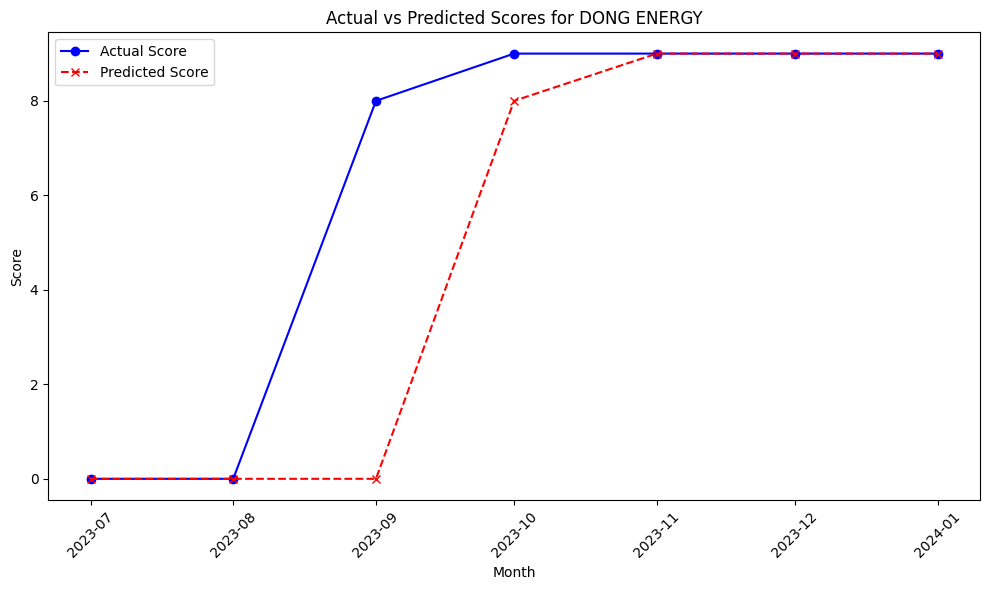

In [32]:
import matplotlib.pyplot as plt

# Filtern des DataFrames für das spezifische Unternehmen und die Praxis
specific_df = filtered_results[
    (filtered_results['Company Name Full'] == 'AEGON') &
    (filtered_results['practice'] == 'CSG-RS-Brand and Reputation Monitoring')
]

# Überprüfen, ob Daten vorhanden sind
if not specific_df.empty:
    # Plot erstellen
    plt.figure(figsize=(10, 6))
    plt.plot(specific_df['month'], specific_df['score'], label='Actual Score', marker='o', color='blue')
    plt.plot(specific_df['month'], specific_df['predicted_score'], label='Predicted Score', linestyle='--', marker='x', color='red')
    plt.title('Actual vs Predicted Scores for DONG ENERGY')
    plt.xlabel('Month')
    plt.ylabel('Score')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Daten für das Unternehmen 'DONG ENERGY' mit der Praxis 'CSG-RS-Brand and Reputation Monitoring' gefunden.")


In [33]:
import pandas as pd
from dateutil.relativedelta import relativedelta

# Den letzten Monat im Testdatensatz finden
last_month = test_df['month'].max()

# Zukünftige Monate erstellen
future_months = [last_month + relativedelta(months=i) for i in range(1, 7)]

# Zukünftige Datenpunkte erstellen
future_df = pd.DataFrame(future_months, columns=['month'])

# Annahme: Wir verwenden die gleichen encoded Werte für 'practice' und 'supersector' 
# für alle zukünftigen Datenpunkte. Hier verwenden wir Beispielwerte.
# In der Praxis sollten Sie die tatsächlichen encodierten Werte Ihrer Kategorien verwenden.
future_df['practice_encoded'] = test_df['practice_encoded'].iloc[0]
future_df['supersector_encoded'] = test_df['supersector_encoded'].iloc[0]

# Stellen Sie sicher, dass die Spaltenreihenfolge in future_df der in X_test entspricht
future_df = future_df[['practice_encoded', 'supersector_encoded']]


In [34]:
# Angenommen, Sie möchten den letzten bekannten Score als 'score_lag1' für die Zukunft verwenden
last_known_score = test_df['score'].iloc[-1]

# 'score_lag1' zu future_df hinzufügen, initial gefüllt mit dem letzten bekannten Score
future_df['score_lag1'] = last_known_score

# Jetzt, da 'future_df' alle benötigten Features enthält, machen Sie die Vorhersagen erneut
future_predictions = model.predict(future_df[['practice_encoded', 'supersector_encoded', 'score_lag1']])

# Fügen Sie die Vorhersagen dem future_df hinzu
future_df['predicted_score'] = future_predictions

# Fügen Sie die 'month' Spalte wieder hinzu, um die Zeitpunkte der Vorhersagen zu zeigen
future_df['month'] = pd.date_range(start=test_df['month'].max() + pd.DateOffset(months=1), periods=6, freq='M')

# Anzeigen der Vorhersagen
print(future_df[['month', 'predicted_score']])



ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- time_since_start


In [112]:
future_df.head(25)

,month,Company Name Full,practice_encoded,supersector_encoded,score_lag1,predicted_score
0,2024-02-29,samhallsbyggnadsbolaget,165,13,7,7.0
1,2024-03-31,samhallsbyggnadsbolaget,165,13,7,7.0
2,2024-04-30,samhallsbyggnadsbolaget,165,13,7,7.0
3,2024-05-31,samhallsbyggnadsbolaget,165,13,7,7.0
4,2024-06-30,samhallsbyggnadsbolaget,165,13,7,7.0
5,2024-07-31,samhallsbyggnadsbolaget,165,13,7,7.0
6,2024-08-31,samhallsbyggnadsbolaget,165,13,7,7.0
7,2024-09-30,samhallsbyggnadsbolaget,165,13,7,7.0
8,2024-10-31,samhallsbyggnadsbolaget,165,13,7,7.0
9,2024-11-30,samhallsbyggnadsbolaget,165,13,7,7.0


In [35]:
test_df.head(15)

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,...,p70,p80,p90,p100,score,time_since_start,score_lag1,practice_encoded,supersector_encoded,predicted_score
30,30,BMI-CCF-Capability Focus,3I GRP,2023-07-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,29,0.0,0,5,0.0
31,31,BMI-CCF-Capability Focus,3I GRP,2023-08-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,6.849546,0,30,0.0,0,5,0.0
32,32,BMI-CCF-Capability Focus,3I GRP,2023-09-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,31,0.0,0,5,0.0
33,33,BMI-CCF-Capability Focus,3I GRP,2023-10-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,2.697146,0,32,0.0,0,5,0.0
34,34,BMI-CCF-Capability Focus,3I GRP,2023-11-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,1.283615,0,33,0.0,0,5,0.0
35,35,BMI-CCF-Capability Focus,3I GRP,2023-12-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,5.059675,0,34,0.0,0,5,0.0
36,36,BMI-CCF-Capability Focus,3I GRP,2024-01-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,35,0.0,0,5,0.0
19640,19640,BMI-CCF-Core Development,3I GRP,2023-07-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,12.494085,20.436623,29.124107,120.793164,8,29,0.0,1,5,0.0
19641,19641,BMI-CCF-Core Development,3I GRP,2023-08-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,9.459642,22.843508,94.346716,239.488294,8,30,8.0,1,5,8.0
19642,19642,BMI-CCF-Core Development,3I GRP,2023-09-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,5.981606,18.169590,24.828342,209.972244,8,31,8.0,1,5,8.0


In [37]:
import pandas as pd

# Vorausgesetzt, test_df, model, df, und die entsprechenden Variablen sind bereits definiert

# Erstellen der zukünftigen Datenpunkte
future_months = pd.date_range(start=test_df['month'].max() + pd.DateOffset(months=1), periods=24, freq='M')
future_df = pd.DataFrame({
    'month': future_months,
    'Company Name Full': [company_name_for_future] * len(future_months),  # Unternehmensname für alle zukünftigen Monate
}).assign(
    practice_encoded = test_df.loc[test_df['Company Name Full'] == company_name_for_future, 'practice_encoded'].iloc[-1],
    supersector_encoded = test_df.loc[test_df['Company Name Full'] == company_name_for_future, 'supersector_encoded'].iloc[-1],
    score_lag1 = last_known_score  # Anfangswert für score_lag1
)

# Berechnen der Differenz in Monaten zwischen dem aktuellen Monat und dem ersten Monat für den zukünftigen Datensatz
future_df['time_since_start'] = ((future_df['month'] - df['month'].min()).dt.days / 30.44).astype(int)

features_for_prediction = ['practice_encoded', 'supersector_encoded', 'score_lag1', 'time_since_start']

# Vorhersage iterativ für jeden Monat durchführen
for i in range(len(future_df)):
    # Erstellen eines DataFrame für die aktuelle Vorhersage mit den korrekten Spaltennamen
    X_for_prediction = pd.DataFrame([[
        future_df.loc[i, 'practice_encoded'],
        future_df.loc[i, 'supersector_encoded'],
        future_df.loc[i, 'score_lag1'],
        future_df.loc[i, 'time_since_start']
    ]], columns=features_for_prediction)
    
    # Vorhersage machen
    predicted_score = model.predict(X_for_prediction)[0]
    
    # Vorhersage für die aktuelle Zeile speichern
    future_df.loc[i, 'predicted_score'] = predicted_score
    
    # 'score_lag1' für die nächste Vorhersage aktualisieren, wenn nicht der letzte Durchlauf
    if i + 1 < len(future_df):
        future_df.loc[i + 1, 'score_lag1'] = predicted_score

# Anzeigen der Vorhersagen mit Unternehmensbezug
print(future_df[['month', 'Company Name Full', 'predicted_score']])


        month        Company Name Full  predicted_score
0  2024-02-29  samhallsbyggnadsbolaget          7.00125
1  2024-03-31  samhallsbyggnadsbolaget          7.00125
2  2024-04-30  samhallsbyggnadsbolaget          7.00125
3  2024-05-31  samhallsbyggnadsbolaget          7.00125
4  2024-06-30  samhallsbyggnadsbolaget          7.00125
5  2024-07-31  samhallsbyggnadsbolaget          7.00125
6  2024-08-31  samhallsbyggnadsbolaget          7.00125
7  2024-09-30  samhallsbyggnadsbolaget          7.00125
8  2024-10-31  samhallsbyggnadsbolaget          7.00125
9  2024-11-30  samhallsbyggnadsbolaget          7.00125
10 2024-12-31  samhallsbyggnadsbolaget          7.00125
11 2025-01-31  samhallsbyggnadsbolaget          7.00125
12 2025-02-28  samhallsbyggnadsbolaget          7.00125
13 2025-03-31  samhallsbyggnadsbolaget          7.00125
14 2025-04-30  samhallsbyggnadsbolaget          7.00125
15 2025-05-31  samhallsbyggnadsbolaget          7.00125
16 2025-06-30  samhallsbyggnadsbolaget          

/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/4082910566.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_months = pd.date_range(start=test_df['month'].max() + pd.DateOffset(months=1), periods=24, freq='M')
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/4082910566.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.00125' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  future_df.loc[i + 1, 'score_lag1'] = predicted_score


In [86]:
test_df.head()

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,...,p60,p70,p80,p90,p100,score,score_lag1,practice_encoded,supersector_encoded,predicted_score
30,30,BMI-CCF-Capability Focus,3I GRP,2023-07-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0,0.0,0,5,0.053552
31,31,BMI-CCF-Capability Focus,3I GRP,2023-08-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.849546,0,0.0,0,5,0.053552
32,32,BMI-CCF-Capability Focus,3I GRP,2023-09-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0,0.0,0,5,0.053552
33,33,BMI-CCF-Capability Focus,3I GRP,2023-10-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.697146,0,0.0,0,5,0.053552
34,34,BMI-CCF-Capability Focus,3I GRP,2023-11-01,Financial Services,CCF,BMI,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.283615,0,0.0,0,5,0.053552


In [13]:
# Angenommene Kodierung für die Praxis "CSG-RS-Brand and Reputation Monitoring"
practice_encoded_value = 0

# Bestimmen des Unternehmensnamens für die Zukunftsvorhersagen (beispielhaft)
company_name_for_future = "3I GRP"  # Ersetzen Sie dies durch den tatsächlichen Unternehmensnamen, falls vorhanden

# Erstellen der zukünftigen Datenpunkte
future_months = pd.date_range(start=test_df['month'].max() + pd.DateOffset(months=1), periods=24, freq='M')
future_df = pd.DataFrame({
    'month': future_months,
    'Company Name Full': [company_name_for_future] * len(future_months),
    'practice_encoded': [practice_encoded_value] * len(future_months),
})

# Ermitteln des letzten bekannten Scores für die spezifische Praxis
last_known_score = test_df.loc[(test_df['practice_encoded'] == practice_encoded_value) & 
                               (test_df['Company Name Full'] == company_name_for_future), 'score'].iloc[-1]

# Ermitteln des supersector_encoded Werts für das Unternehmen und die Praxis
supersector_encoded_value = test_df.loc[(test_df['practice_encoded'] == practice_encoded_value) & 
                                        (test_df['Company Name Full'] == company_name_for_future), 'supersector_encoded'].iloc[-1]

# Hinzufügen der benötigten Features zu `future_df`
future_df['supersector_encoded'] = supersector_encoded_value
future_df['score_lag1'] = last_known_score

# Vorhersagen mit dem trainierten Modell machen
future_df['predicted_score'] = model.predict(future_df[['practice_encoded', 'supersector_encoded', 'score_lag1']])

# Anzeigen der Vorhersagen mit Unternehmens- und Praxisbezug
print(future_df[['month', 'Company Name Full', 'predicted_score']])


        month Company Name Full  predicted_score
0  2024-02-29            3I GRP         0.053552
1  2024-03-31            3I GRP         0.053552
2  2024-04-30            3I GRP         0.053552
3  2024-05-31            3I GRP         0.053552
4  2024-06-30            3I GRP         0.053552
5  2024-07-31            3I GRP         0.053552
6  2024-08-31            3I GRP         0.053552
7  2024-09-30            3I GRP         0.053552
8  2024-10-31            3I GRP         0.053552
9  2024-11-30            3I GRP         0.053552
10 2024-12-31            3I GRP         0.053552
11 2025-01-31            3I GRP         0.053552
12 2025-02-28            3I GRP         0.053552
13 2025-03-31            3I GRP         0.053552
14 2025-04-30            3I GRP         0.053552
15 2025-05-31            3I GRP         0.053552
16 2025-06-30            3I GRP         0.053552
17 2025-07-31            3I GRP         0.053552
18 2025-08-31            3I GRP         0.053552
19 2025-09-30       

/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_94242/1879388259.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_months = pd.date_range(start=test_df['month'].max() + pd.DateOffset(months=1), periods=24, freq='M')


In [19]:
# Funktion zur iterativen Vorhersage für zukünftige Monate
def iterative_predictions(model, initial_data, num_months):
    future_predictions = []
    current_data = initial_data.copy()
    
    for _ in range(num_months):
        # Vorhersage für den aktuellen Datenpunkt machen
        predicted_score = model.predict(current_data[['practice_encoded', 'supersector_encoded', 'score_lag1']].values.reshape(1, -1))[0]
        
        # Vorhersage speichern
        future_predictions.append(predicted_score)
        
        # Aktualisieren des score_lag1 für den nächsten Monat basierend auf der aktuellen Vorhersage
        current_data['score_lag1'] = predicted_score
    
    return future_predictions

# Startdaten für die erste Vorhersage
initial_data = {
    'practice_encoded': practice_encoded_value,  # Der bereits definierte kodierte Wert der Praxis
    'supersector_encoded': supersector_encoded_value,  # Der kodierte Wert des Supersektors
    'score_lag1': last_known_score,  # Der letzte bekannte Score
}

initial_data_df = pd.DataFrame([initial_data])

# Generieren iterativer Vorhersagen für die nächsten 6 Monate
num_future_months = 56
future_scores = iterative_predictions(model, initial_data_df, num_future_months)

# Zukünftige Monate und ihre vorhergesagten Scores
future_months = pd.date_range(start=test_df['month'].max() + pd.DateOffset(months=1), periods=num_future_months, freq='M')
future_predictions_df = pd.DataFrame({
    'month': future_months,
    'predicted_score': future_scores
})

print(future_predictions_df)


/Users/maxbreitruck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 3 features, but RandomForestRegressor is expecting 4 features as input.